<a href="https://colab.research.google.com/github/jmoralespineda/TEORIA_DE_SE-ALES/blob/main/Taller_en_clase.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Taller en clase**

#**Base de datos: wheather_feature - variable de interes: wind_speed**
#Julian David Morales Pineda

In [2]:
import pandas as pd

# Replace 'your_database.csv' with the actual path to your database file
try:
    df = pd.read_csv('wheather_feature.txt')
    print("Database loaded successfully!")
    display(df.head())
except FileNotFoundError:
    print("Error: The file 'wheather_feature.txt' was not found. Please provide the correct path to your database file.")
except Exception as e:
    print(f"An error occurred: {e}")

Database loaded successfully!


,dt_iso,city_name,temp,temp_min,temp_max,pressure,humidity,wind_speed,wind_deg,rain_1h,rain_3h,snow_3h,clouds_all,weather_id,weather_main,weather_description,weather_icon
0,2015-01-01 00:00:00+01:00,Valencia,270.475,270.475,270.475,1001.0,77.0,1.0,62.0,0.0,0.0,0.0,0.0,800.0,clear,sky is clear,01n
1,2015-01-01 01:00:00+01:00,Valencia,270.475,270.475,270.475,1001.0,77.0,1.0,62.0,0.0,0.0,0.0,0.0,800.0,clear,sky is clear,01n
2,2015-01-01 02:00:00+01:00,Valencia,269.686,269.686,269.686,1002.0,78.0,0.0,23.0,0.0,0.0,0.0,0.0,800.0,clear,sky is clear,01n
3,2015-01-01 03:00:00+01:00,Valencia,269.686,269.686,269.686,1002.0,78.0,0.0,23.0,0.0,0.0,0.0,0.0,800.0,clear,sky is clear,01n
4,2015-01-01 04:00:00+01:00,Valencia,269.686,269.686,269.686,1002.0,78.0,0.0,23.0,0.0,0.0,0.0,0.0,800.0,clear,sky is clear,01n


#separamos la variable de interes

In [3]:
wind_speed_data = df['wind_speed']
display(wind_speed_data.head())

,wind_speed
0,1.0
1,1.0
2,0.0
3,0.0
4,0.0


#Señal en el tiempo

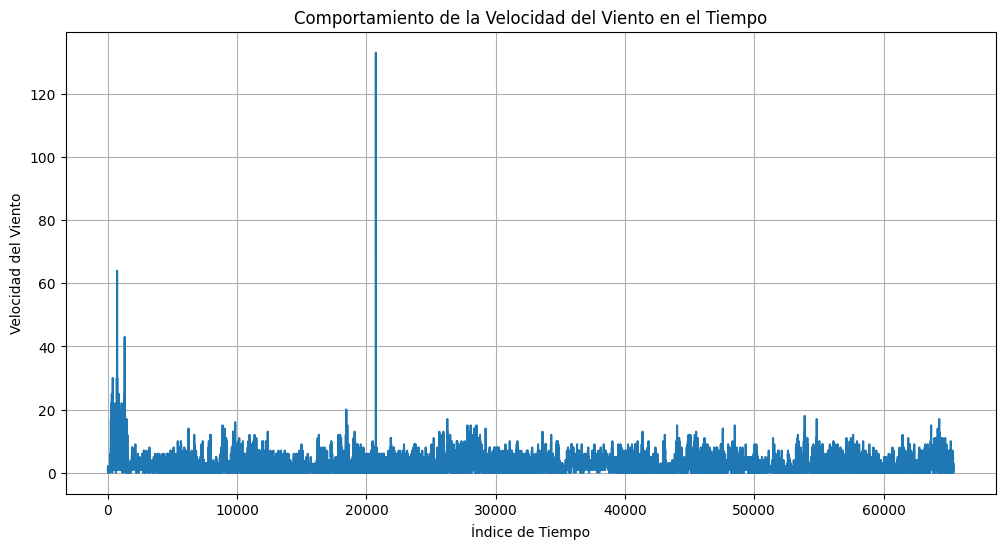

In [4]:
import matplotlib.pyplot as plt

# Take the variable of interest (wind_speed_data)
# This variable already holds the 'wind_speed' column extracted earlier
wind_speed_time_series = wind_speed_data

# Create a figure and an axes for the plot
plt.figure(figsize=(12, 6)) # Set the size of the plot

# Plot the time series data
# We are plotting the wind_speed values against their index (representing time)
plt.plot(wind_speed_time_series)

# Add a title to the plot
plt.title('Comportamiento de la Velocidad del Viento en el Tiempo')

# Add labels to the x and y axes
plt.xlabel('Índice de Tiempo')
plt.ylabel('Velocidad del Viento')

# Add a grid to the plot for better readability
plt.grid(True)

# Display the plot
plt.show()

#**Espectro de la señal**

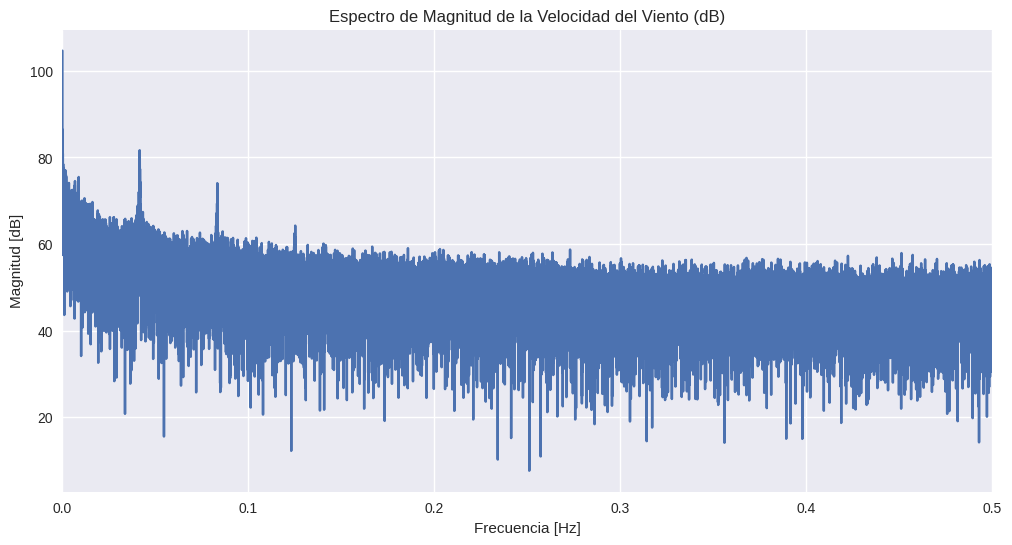

In [28]:
import numpy as np
import matplotlib.pyplot as plt

# Remove any potential NaN values from the time series data before performing FFT
wind_speed_time_series_clean = wind_speed_time_series.dropna()

# Calculate sampling frequency (assuming hourly data, so delta_t = 1 hour)
# If your data has a different sampling interval, adjust delta_t accordingly.
delta_t = 1 # Assuming hourly data, so 1 hour between samples
fs = 1 / delta_t # Sampling frequency in Hz (or cycles per hour)
nyquist = fs / 2 # Nyquist frequency

# Perform the Fast Fourier Transform (FFT)
fft_result = np.fft.fft(wind_speed_time_series_clean)

# Get the magnitude of the spectrum and convert to decibels (dB)
# We only need the first half for a real signal (positive frequencies)
fft_magnitude = np.abs(fft_result[:len(fft_result)//2])
# Add a small epsilon to avoid log(0)
epsilon = 1e-10
fft_magnitude_db = 10 * np.log10(fft_magnitude + epsilon)

# Create the frequency axis
# The frequency values are from 0 up to the Nyquist frequency
frequencies = np.fft.fftfreq(len(wind_speed_time_series_clean), d=delta_t)[:len(fft_result)//2]

# Create a figure and axes for the spectrum plot
plt.figure(figsize=(12, 6))

# Plot the magnitude spectrum in dB
plt.plot(frequencies, fft_magnitude_db)

# Add title and labels
plt.title('Espectro de Magnitud de la Velocidad del Viento (dB)')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Magnitud [dB]')

# Add a grid for better readability
plt.grid(True)

# Set x-axis limit to Nyquist frequency for a wider view
plt.xlim([0, nyquist])

# Display the plot
plt.show()

##Autocorrelacion antes del filtrado

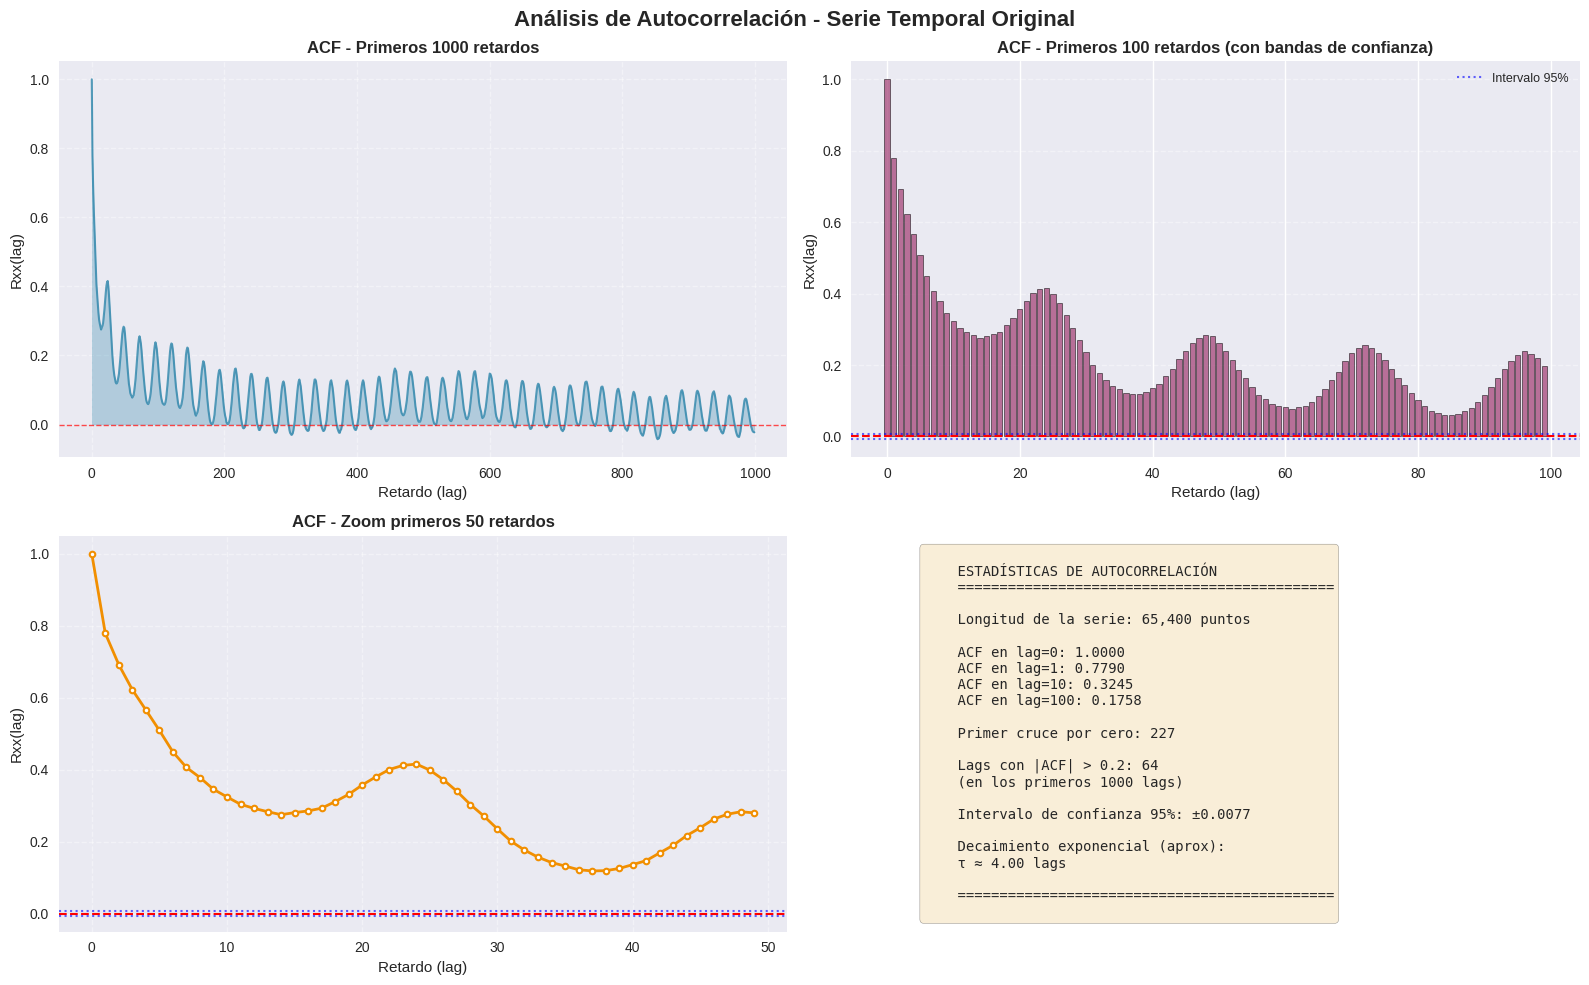


RESUMEN DE AUTOCORRELACIÓN
ACF máxima (lag>0): 0.7790 en lag 1
ACF mínima: -0.0768 en lag 14702



In [16]:
import torch
import matplotlib.pyplot as plt
import numpy as np

plt.style.use("seaborn-v0_8")

# Usar la señal original
x_original = torch.tensor(wind_speed_time_series_clean.values, dtype=torch.float32)

if len(x_original) < 2:
    print("Error: La serie es demasiado corta para calcular autocorrelación.")
else:
    # Quitar la media
    x_mean_original = x_original - torch.mean(x_original)

    # FFT y PSD
    fft_x_original = torch.fft.fft(x_mean_original)
    psd_x_original = torch.abs(fft_x_original) ** 2

    # Autocorrelación via IFFT
    acf_full_original = torch.fft.ifft(psd_x_original)
    acf_original = torch.real(acf_full_original)
    acf_original = acf_original / acf_original[0]  # Normalizar en lag=0

    # Solo retardos positivos
    N_original = len(x_original)
    acf_original = acf_original[:N_original]
    lags_original = torch.arange(len(acf_original))

    # ===============================
    # Visualización mejorada
    # ===============================
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    fig.suptitle('Análisis de Autocorrelación - Serie Temporal Original',
                 fontsize=16, fontweight='bold')

    # 1. ACF completa (primeros 1000 lags)
    max_lags_1 = min(1000, len(acf_original))
    axes[0, 0].plot(lags_original[:max_lags_1].numpy(),
                    acf_original[:max_lags_1].numpy(),
                    color='#2E86AB', linewidth=1.5, alpha=0.8)
    axes[0, 0].axhline(y=0, color='red', linestyle='--', linewidth=1, alpha=0.7)
    axes[0, 0].fill_between(lags_original[:max_lags_1].numpy(),
                            acf_original[:max_lags_1].numpy(),
                            0, alpha=0.3, color='#2E86AB')
    axes[0, 0].set_title('ACF - Primeros 1000 retardos', fontsize=12, fontweight='bold')
    axes[0, 0].set_xlabel('Retardo (lag)', fontsize=11)
    axes[0, 0].set_ylabel('Rxx(lag)', fontsize=11)
    axes[0, 0].grid(True, linestyle='--', alpha=0.4)

    # 2. ACF detallada (primeros 100 lags) - barras
    max_lags_2 = min(100, len(acf_original))
    axes[0, 1].bar(lags_original[:max_lags_2].numpy(),
                   acf_original[:max_lags_2].numpy(),
                   color='#A23B72', width=0.8, alpha=0.7, edgecolor='black', linewidth=0.5)
    axes[0, 1].axhline(y=0, color='red', linestyle='--', linewidth=1.5)
    # Bandas de confianza (aproximadas)
    conf_level = 1.96 / torch.sqrt(torch.tensor(len(x_original), dtype=torch.float32))
    axes[0, 1].axhline(y=conf_level.item(), color='blue', linestyle=':',
                       linewidth=1.5, alpha=0.6, label='Intervalo 95%')
    axes[0, 1].axhline(y=-conf_level.item(), color='blue', linestyle=':',
                       linewidth=1.5, alpha=0.6)
    axes[0, 1].set_title('ACF - Primeros 100 retardos (con bandas de confianza)',
                         fontsize=12, fontweight='bold')
    axes[0, 1].set_xlabel('Retardo (lag)', fontsize=11)
    axes[0, 1].set_ylabel('Rxx(lag)', fontsize=11)
    axes[0, 1].legend(loc='upper right', fontsize=9)
    axes[0, 1].grid(True, linestyle='--', alpha=0.4, axis='y')

    # 3. ACF zoom (primeros 50 lags) - línea con marcadores
    max_lags_3 = min(50, len(acf_original))
    axes[1, 0].plot(lags_original[:max_lags_3].numpy(),
                    acf_original[:max_lags_3].numpy(),
                    color='#F18F01', linewidth=2, marker='o',
                    markersize=4, markerfacecolor='white',
                    markeredgewidth=1.5, markeredgecolor='#F18F01')
    axes[1, 0].axhline(y=0, color='red', linestyle='--', linewidth=1.5)
    axes[1, 0].axhline(y=conf_level.item(), color='blue', linestyle=':',
                       linewidth=1.5, alpha=0.6)
    axes[1, 0].axhline(y=-conf_level.item(), color='blue', linestyle=':',
                       linewidth=1.5, alpha=0.6)
    axes[1, 0].set_title('ACF - Zoom primeros 50 retardos', fontsize=12, fontweight='bold')
    axes[1, 0].set_xlabel('Retardo (lag)', fontsize=11)
    axes[1, 0].set_ylabel('Rxx(lag)', fontsize=11)
    axes[1, 0].grid(True, linestyle='--', alpha=0.4)

    # 4. Estadísticas y decaimiento
    axes[1, 1].axis('off')

    # Calcular estadísticas
    first_zero_crossing = torch.where(acf_original[:max_lags_1] < 0)[0]
    if len(first_zero_crossing) > 0:
        first_zero = first_zero_crossing[0].item()
    else:
        first_zero = "No encontrado"

    # Encontrar picos significativos
    threshold = 0.2
    significant_lags = torch.where(torch.abs(acf_original[:max_lags_1]) > threshold)[0]

    stats_text = f"""
    ESTADÍSTICAS DE AUTOCORRELACIÓN
    {'='*45}

    Longitud de la serie: {len(x_original):,} puntos

    ACF en lag=0: {acf_original[0].item():.4f}
    ACF en lag=1: {acf_original[1].item():.4f}
    ACF en lag=10: {acf_original[min(10, len(acf_original)-1)].item():.4f}
    ACF en lag=100: {acf_original[min(100, len(acf_original)-1)].item():.4f}

    Primer cruce por cero: {first_zero}

    Lags con |ACF| > {threshold}: {len(significant_lags)}
    (en los primeros {max_lags_1} lags)

    Intervalo de confianza 95%: ±{conf_level.item():.4f}

    Decaimiento exponencial (aprox):
    τ ≈ {-1/torch.log(torch.abs(acf_original[1])).item():.2f} lags

    {'='*45}
    """

    axes[1, 1].text(0.1, 0.5, stats_text, fontsize=10, family='monospace',
                    verticalalignment='center', bbox=dict(boxstyle='round',
                    facecolor='wheat', alpha=0.5))

    plt.tight_layout()
    plt.show()

    # Imprimir resumen en consola
    print("\n" + "="*50)
    print("RESUMEN DE AUTOCORRELACIÓN")
    print("="*50)
    print(f"ACF máxima (lag>0): {torch.max(acf_original[1:]).item():.4f} en lag {torch.argmax(acf_original[1:]).item() + 1}")
    print(f"ACF mínima: {torch.min(acf_original).item():.4f} en lag {torch.argmin(acf_original).item()}")
    print("="*50 + "\n")

#**Filtrado de la señal con banda util**

Frecuencia de muestreo: 1.000000 Hz (Nyquist = 0.500000 Hz)
Delta t entre muestras: 1


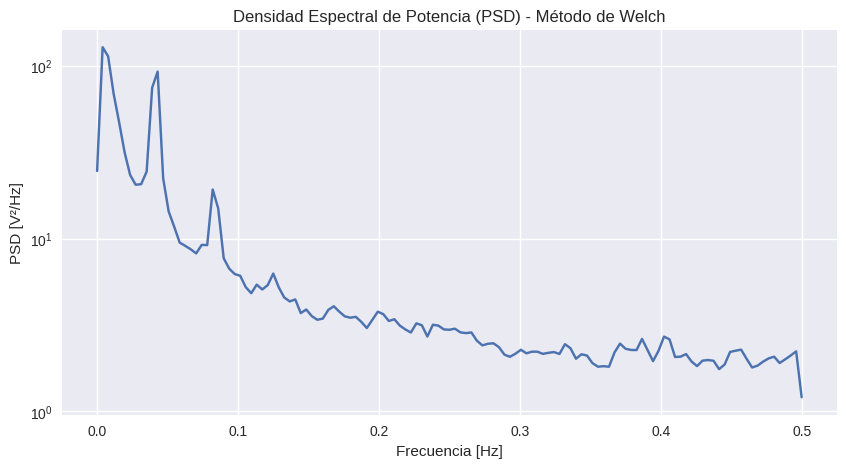

Banda de paso normalizada: [0.0020, 0.1000]


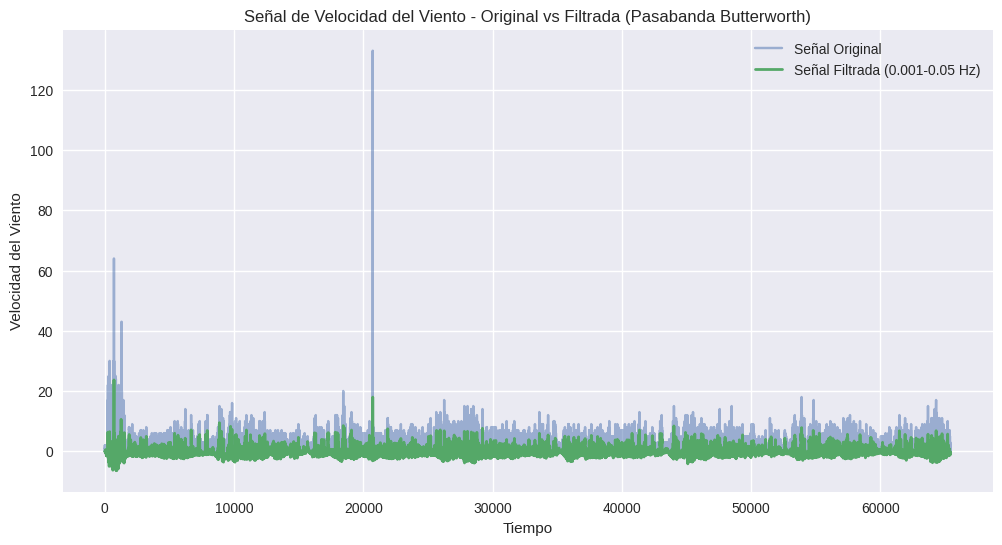

In [26]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, welch

# ===============================
# 1. Calcular frecuencia de muestreo automáticamente
# ===============================
time_index = wind_speed_time_series_clean.index

if np.issubdtype(time_index.dtype, np.datetime64):
    # Caso 1: índice de fechas
    delta_t = (time_index[1] - time_index[0]).total_seconds()  # segundos
else:
    # Caso 2: índice numérico
    # Assuming the index represents hourly data if not datetime
    # If your data has a different sampling interval, you'll need to adjust this.
    delta_t = time_index[1] - time_index[0] if len(time_index) > 1 else 1 # Assume delta_t is 1 if only one data point


fs = 1 / delta_t           # Frecuencia de muestreo (Hz o unidades^-1)
nyquist = fs / 2

print(f"Frecuencia de muestreo: {fs:.6f} Hz (Nyquist = {nyquist:.6f} Hz)")
print(f"Delta t entre muestras: {delta_t}")

# ===============================
# 2. Analizar espectro con Welch (para identificar banda útil)
# ===============================
# Extract values as a NumPy array for compatibility with scipy.signal.welch
wind_speed_values = wind_speed_time_series_clean.values

f, Pxx = welch(wind_speed_values, fs=fs, nperseg=256)

plt.figure(figsize=(10, 5))
plt.semilogy(f, Pxx)
plt.title("Densidad Espectral de Potencia (PSD) - Método de Welch")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("PSD [V²/Hz]")
plt.grid(True)
plt.show()

# ===============================
# 3. Definir banda de paso (ajustar según PSD observada)
# ===============================
# ⚡ Ajusta estos valores según dónde veas energía en el espectro
lowcut = 0.001   # Frecuencia baja de corte
highcut = 0.05   # Frecuencia alta de corte

low = lowcut / nyquist
high = highcut / nyquist

# Asegurar que estén en (0,1)
low = max(low, 1e-6)
high = min(high, 0.999)

print(f"Banda de paso normalizada: [{low:.4f}, {high:.4f}]")

# ===============================
# 4. Crear y aplicar filtro Butterworth
# ===============================
order = 5
# Apply the filter to the NumPy array of values
b, a = butter(order, [low, high], btype="band")
wind_speed_filtered = filtfilt(b, a, wind_speed_values)

# ===============================
# 5. Visualizar señal original vs filtrada
# ===============================
plt.figure(figsize=(12, 6))
# Use the original time index for plotting
plt.plot(time_index, wind_speed_time_series_clean, label="Señal Original", alpha=0.5)
plt.plot(time_index, wind_speed_filtered, label=f"Señal Filtrada ({lowcut}-{highcut} Hz)", linewidth=2)
plt.title("Señal de Velocidad del Viento - Original vs Filtrada (Pasabanda Butterworth)")
plt.xlabel("Tiempo")
plt.ylabel("Velocidad del Viento")
plt.legend()
plt.grid(True)
plt.show()

#**Autocorrelacion de la señal filtrada, comparacion antes y despues del filtrado**

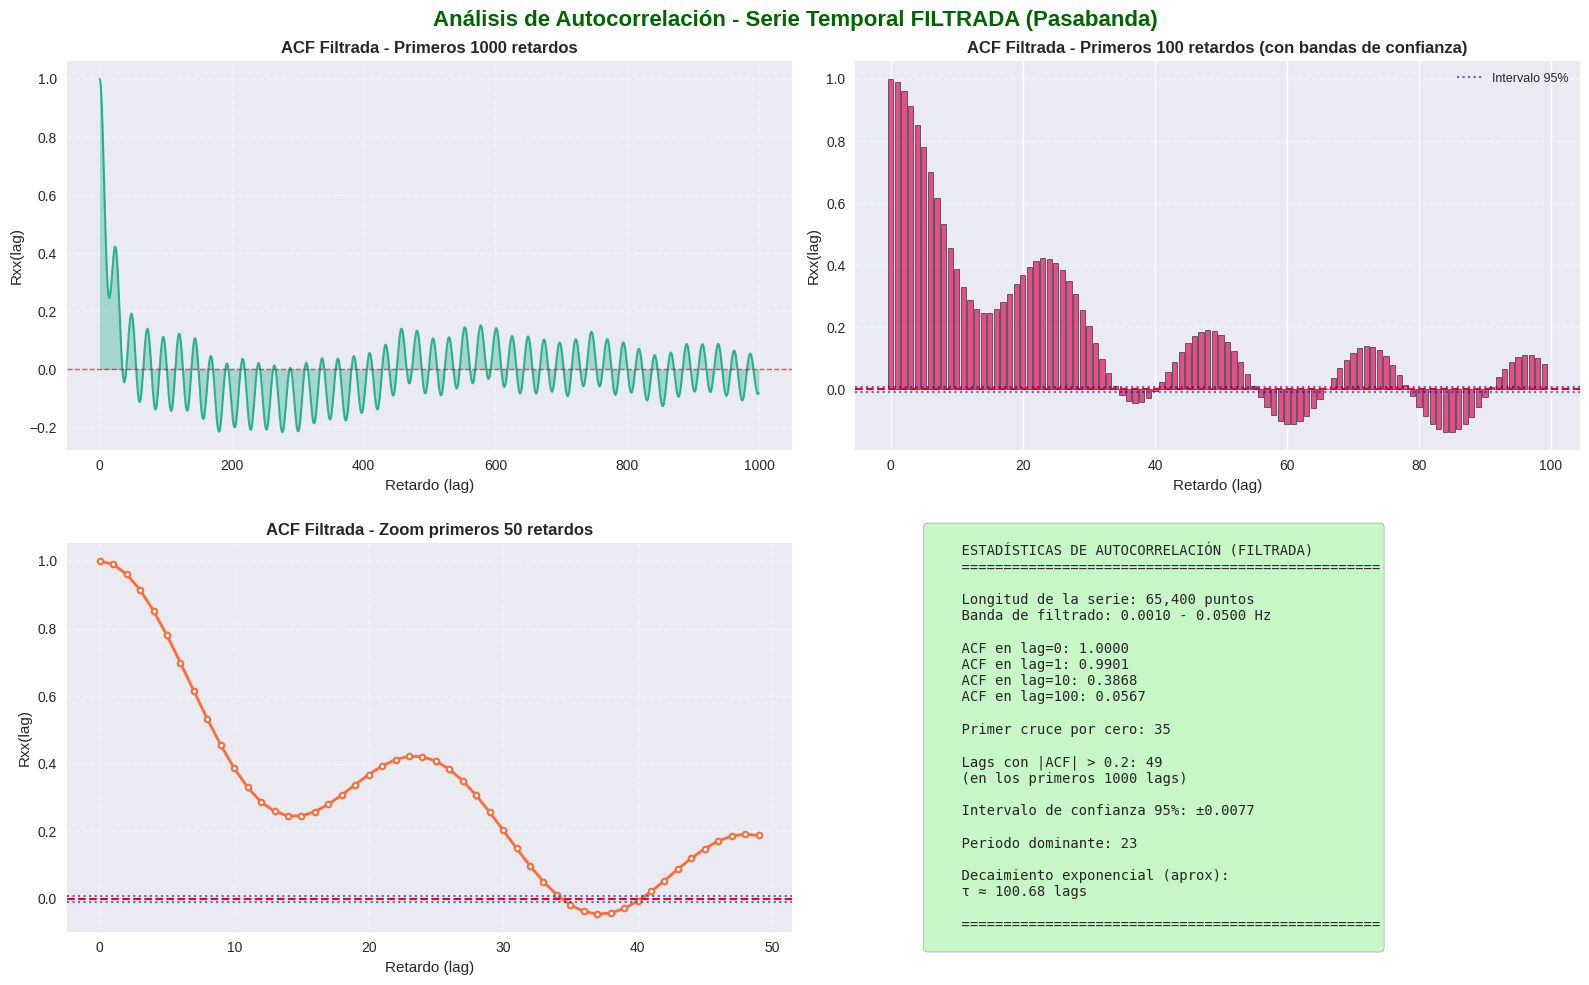


COMPARACIÓN: AUTOCORRELACIÓN ORIGINAL vs FILTRADA


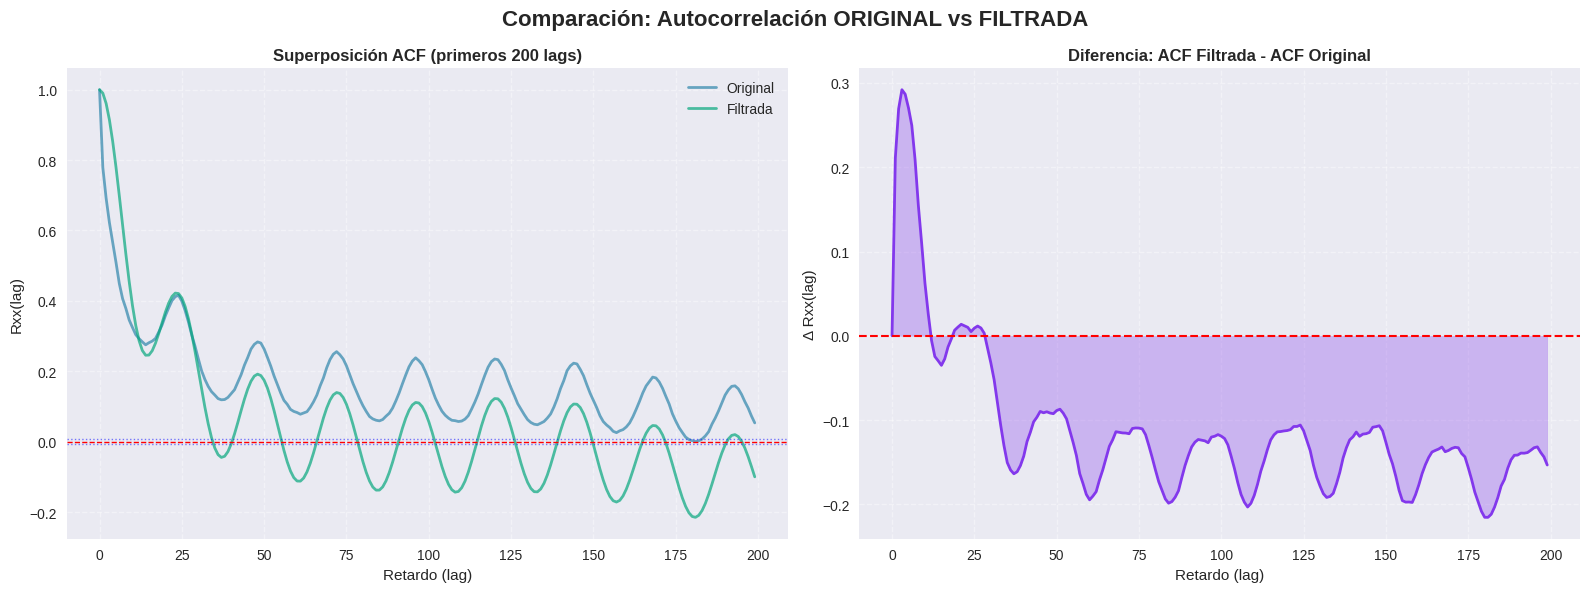


ACF máxima (Original, lag>0): 0.7790
ACF máxima (Filtrada, lag>0): 0.9901

ACF mínima (Original): -0.0768
ACF mínima (Filtrada): -0.2164

Diferencia RMS: 0.1449



In [18]:
import torch
import matplotlib.pyplot as plt
import numpy as np

plt.style.use("seaborn-v0_8")

# ===============================
# Convertir señal filtrada a PyTorch
# ===============================
# Make a copy of the numpy array to avoid the negative stride issue
x_filtered = torch.tensor(wind_speed_filtered.copy(), dtype=torch.float32)

if len(x_filtered) < 2:
    print("Error: La serie filtrada es demasiado corta para calcular autocorrelación.")
else:
    # Quitar la media
    x_mean_filtered = x_filtered - torch.mean(x_filtered)

    # FFT y PSD
    fft_x_filtered = torch.fft.fft(x_mean_filtered)
    psd_x_filtered = torch.abs(fft_x_filtered) ** 2

    # Autocorrelación via IFFT
    acf_full_filtered = torch.fft.ifft(psd_x_filtered)
    acf_filtered = torch.real(acf_full_filtered)
    acf_filtered = acf_filtered / acf_filtered[0]  # Normalizar en lag=0

    # Solo retardos positivos
    N_filtered = len(x_filtered)
    acf_filtered = acf_filtered[:N_filtered]
    lags_filtered = torch.arange(len(acf_filtered))

    # ===============================
    # Visualización mejorada DESPUÉS del filtrado
    # ===============================
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    fig.suptitle('Análisis de Autocorrelación - Serie Temporal FILTRADA (Pasabanda)',
                 fontsize=16, fontweight='bold', color='darkgreen')

    # 1. ACF completa (primeros 1000 lags)
    max_lags_1 = min(1000, len(acf_filtered))
    axes[0, 0].plot(lags_filtered[:max_lags_1].numpy(),
                    acf_filtered[:max_lags_1].numpy(),
                    color='#06A77D', linewidth=1.5, alpha=0.8)
    axes[0, 0].axhline(y=0, color='red', linestyle='--', linewidth=1, alpha=0.7)
    axes[0, 0].fill_between(lags_filtered[:max_lags_1].numpy(),
                            acf_filtered[:max_lags_1].numpy(),
                            0, alpha=0.3, color='#06A77D')
    axes[0, 0].set_title('ACF Filtrada - Primeros 1000 retardos', fontsize=12, fontweight='bold')
    axes[0, 0].set_xlabel('Retardo (lag)', fontsize=11)
    axes[0, 0].set_ylabel('Rxx(lag)', fontsize=11)
    axes[0, 0].grid(True, linestyle='--', alpha=0.4)

    # 2. ACF detallada (primeros 100 lags) - barras
    max_lags_2 = min(100, len(acf_filtered))
    axes[0, 1].bar(lags_filtered[:max_lags_2].numpy(),
                   acf_filtered[:max_lags_2].numpy(),
                   color='#D81159', width=0.8, alpha=0.7, edgecolor='black', linewidth=0.5)
    axes[0, 1].axhline(y=0, color='red', linestyle='--', linewidth=1.5)
    # Bandas de confianza (aproximadas)
    conf_level = 1.96 / torch.sqrt(torch.tensor(len(x_filtered), dtype=torch.float32))
    axes[0, 1].axhline(y=conf_level.item(), color='blue', linestyle=':',
                       linewidth=1.5, alpha=0.6, label='Intervalo 95%')
    axes[0, 1].axhline(y=-conf_level.item(), color='blue', linestyle=':',
                       linewidth=1.5, alpha=0.6)
    axes[0, 1].set_title('ACF Filtrada - Primeros 100 retardos (con bandas de confianza)',
                         fontsize=12, fontweight='bold')
    axes[0, 1].set_xlabel('Retardo (lag)', fontsize=11)
    axes[0, 1].set_ylabel('Rxx(lag)', fontsize=11)
    axes[0, 1].legend(loc='upper right', fontsize=9)
    axes[0, 1].grid(True, linestyle='--', alpha=0.4, axis='y')

    # 3. ACF zoom (primeros 50 lags) - línea con marcadores
    max_lags_3 = min(50, len(acf_filtered))
    axes[1, 0].plot(lags_filtered[:max_lags_3].numpy(),
                    acf_filtered[:max_lags_3].numpy(),
                    color='#FF6B35', linewidth=2, marker='o',
                    markersize=4, markerfacecolor='white',
                    markeredgewidth=1.5, markeredgecolor='#FF6B35')
    axes[1, 0].axhline(y=0, color='red', linestyle='--', linewidth=1.5)
    axes[1, 0].axhline(y=conf_level.item(), color='blue', linestyle=':',
                       linewidth=1.5, alpha=0.6)
    axes[1, 0].axhline(y=-conf_level.item(), color='blue', linestyle=':',
                       linewidth=1.5, alpha=0.6)
    axes[1, 0].set_title('ACF Filtrada - Zoom primeros 50 retardos',
                         fontsize=12, fontweight='bold')
    axes[1, 0].set_xlabel('Retardo (lag)', fontsize=11)
    axes[1, 0].set_ylabel('Rxx(lag)', fontsize=11)
    axes[1, 0].grid(True, linestyle='--', alpha=0.4)

    # 4. Estadísticas y decaimiento
    axes[1, 1].axis('off')

    # Calcular estadísticas
    first_zero_crossing = torch.where(acf_filtered[:max_lags_1] < 0)[0]
    if len(first_zero_crossing) > 0:
        first_zero = first_zero_crossing[0].item()
    else:
        first_zero = "No encontrado"

    # Encontrar picos significativos
    threshold = 0.2
    significant_lags = torch.where(torch.abs(acf_filtered[:max_lags_1]) > threshold)[0]

    # Calcular periodicidad dominante (si existe)
    acf_abs = torch.abs(acf_filtered[1:max_lags_3])
    local_maxima = []
    for i in range(1, len(acf_abs) - 1):
        if acf_abs[i] > acf_abs[i-1] and acf_abs[i] > acf_abs[i+1] and acf_abs[i] > 0.3:
            local_maxima.append(i + 1)

    if len(local_maxima) > 0:
        dominant_period = local_maxima[0]
    else:
        dominant_period = "No detectado"

    stats_text = f"""
    ESTADÍSTICAS DE AUTOCORRELACIÓN (FILTRADA)
    {'='*50}

    Longitud de la serie: {len(x_filtered):,} puntos
    Banda de filtrado: {lowcut:.4f} - {highcut:.4f} Hz

    ACF en lag=0: {acf_filtered[0].item():.4f}
    ACF en lag=1: {acf_filtered[1].item():.4f}
    ACF en lag=10: {acf_filtered[min(10, len(acf_filtered)-1)].item():.4f}
    ACF en lag=100: {acf_filtered[min(100, len(acf_filtered)-1)].item():.4f}

    Primer cruce por cero: {first_zero}

    Lags con |ACF| > {threshold}: {len(significant_lags)}
    (en los primeros {max_lags_1} lags)

    Intervalo de confianza 95%: ±{conf_level.item():.4f}

    Periodo dominante: {dominant_period}

    Decaimiento exponencial (aprox):
    τ ≈ {-1/torch.log(torch.abs(acf_filtered[1])).item():.2f} lags

    {'='*50}
    """

    axes[1, 1].text(0.1, 0.5, stats_text, fontsize=10, family='monospace',
                    verticalalignment='center', bbox=dict(boxstyle='round',
                    facecolor='lightgreen', alpha=0.5))

    plt.tight_layout()
    plt.show()

    # ===============================
    # Comparación ANTES vs DESPUÉS del filtrado
    # ===============================
    print("\n" + "="*70)
    print("COMPARACIÓN: AUTOCORRELACIÓN ORIGINAL vs FILTRADA")
    print("="*70)

    # Calcular también ACF de la señal original para comparar
    x_original = torch.tensor(wind_speed_time_series_clean.values, dtype=torch.float32)
    x_mean_original = x_original - torch.mean(x_original)
    fft_x_original = torch.fft.fft(x_mean_original)
    psd_x_original = torch.abs(fft_x_original) ** 2
    acf_full_original = torch.fft.ifft(psd_x_original)
    acf_original = torch.real(acf_full_original)
    acf_original = acf_original / acf_original[0]

    # Gráfica comparativa
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle('Comparación: Autocorrelación ORIGINAL vs FILTRADA',
                 fontsize=16, fontweight='bold')

    max_compare = min(200, len(acf_original), len(acf_filtered))

    # Subplot 1: Superposición
    axes[0].plot(lags_filtered[:max_compare].numpy(),
                 acf_original[:max_compare].numpy(),
                 color='#2E86AB', linewidth=2, alpha=0.7, label='Original')
    axes[0].plot(lags_filtered[:max_compare].numpy(),
                 acf_filtered[:max_compare].numpy(),
                 color='#06A77D', linewidth=2, alpha=0.7, label='Filtrada')
    axes[0].axhline(y=0, color='red', linestyle='--', linewidth=1)
    axes[0].axhline(y=conf_level.item(), color='blue', linestyle=':', linewidth=1, alpha=0.5)
    axes[0].axhline(y=-conf_level.item(), color='blue', linestyle=':', linewidth=1, alpha=0.5)
    axes[0].set_title('Superposición ACF (primeros 200 lags)', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('Retardo (lag)', fontsize=11)
    axes[0].set_ylabel('Rxx(lag)', fontsize=11)
    axes[0].legend(loc='upper right', fontsize=10)
    axes[0].grid(True, linestyle='--', alpha=0.4)

    # Subplot 2: Diferencia
    diff_acf = acf_filtered[:max_compare] - acf_original[:max_compare]
    axes[1].plot(lags_filtered[:max_compare].numpy(),
                 diff_acf.numpy(),
                 color='#8338EC', linewidth=2)
    axes[1].fill_between(lags_filtered[:max_compare].numpy(),
                         diff_acf.numpy(),
                         0, alpha=0.3, color='#8338EC')
    axes[1].axhline(y=0, color='red', linestyle='--', linewidth=1.5)
    axes[1].set_title('Diferencia: ACF Filtrada - ACF Original', fontsize=12, fontweight='bold')
    axes[1].set_xlabel('Retardo (lag)', fontsize=11)
    axes[1].set_ylabel('Δ Rxx(lag)', fontsize=11)
    axes[1].grid(True, linestyle='--', alpha=0.4)

    plt.tight_layout()
    plt.show()

    # Resumen numérico
    print(f"\nACF máxima (Original, lag>0): {torch.max(acf_original[1:]).item():.4f}")
    print(f"ACF máxima (Filtrada, lag>0): {torch.max(acf_filtered[1:]).item():.4f}")
    print(f"\nACF mínima (Original): {torch.min(acf_original).item():.4f}")
    print(f"ACF mínima (Filtrada): {torch.min(acf_filtered).item():.4f}")
    print(f"\nDiferencia RMS: {torch.sqrt(torch.mean(diff_acf**2)).item():.4f}")
    print("="*70 + "\n")

#**Comparaciones, PSD, AUTOCORRELACION, DISTRICUCION EN TIEMPO Y FRECUENCIA**

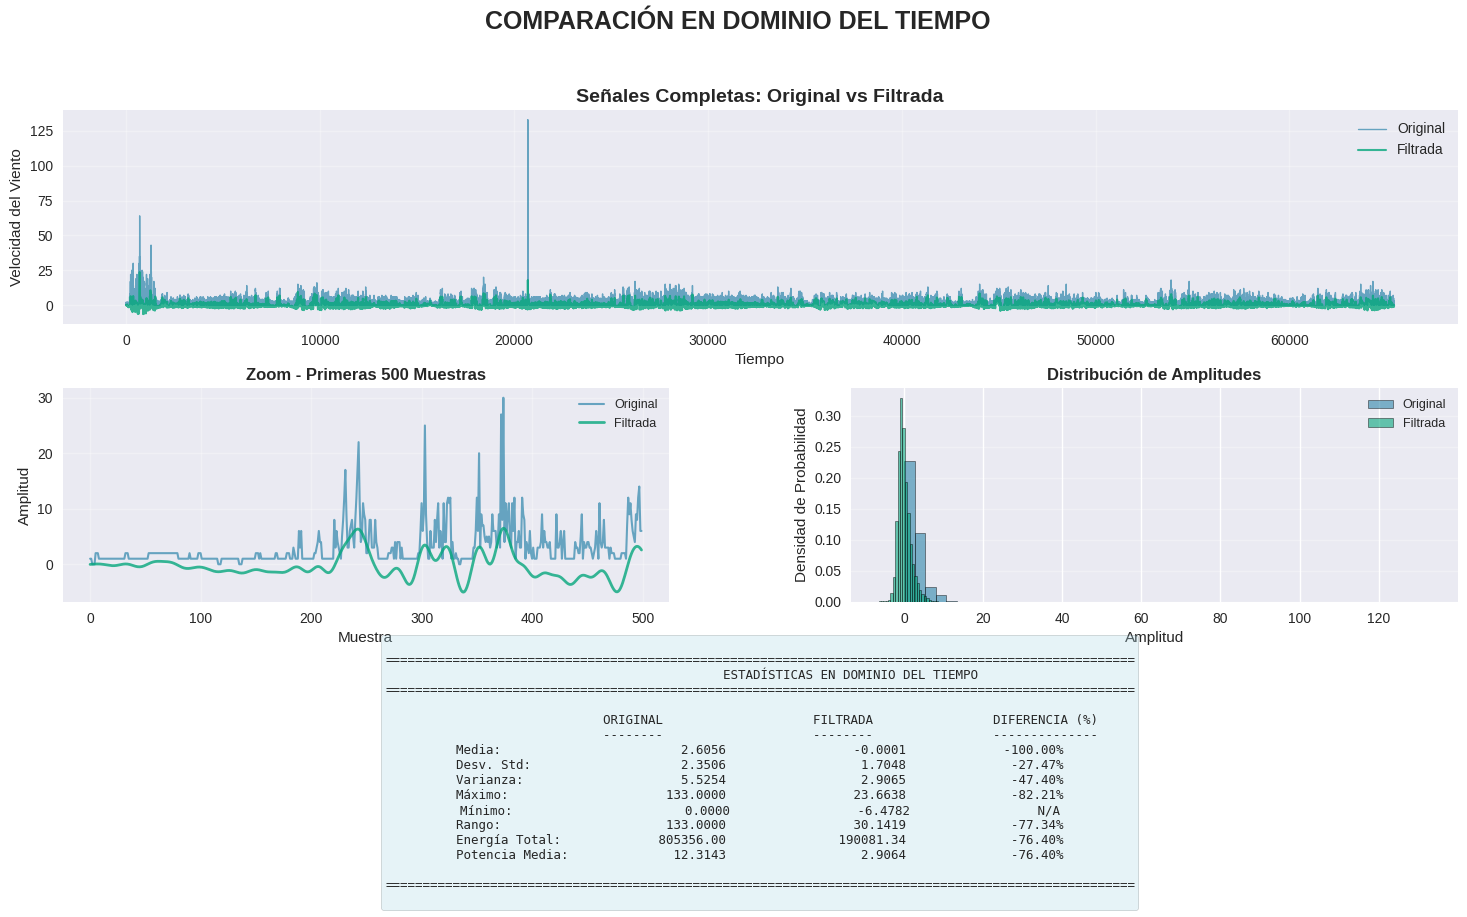

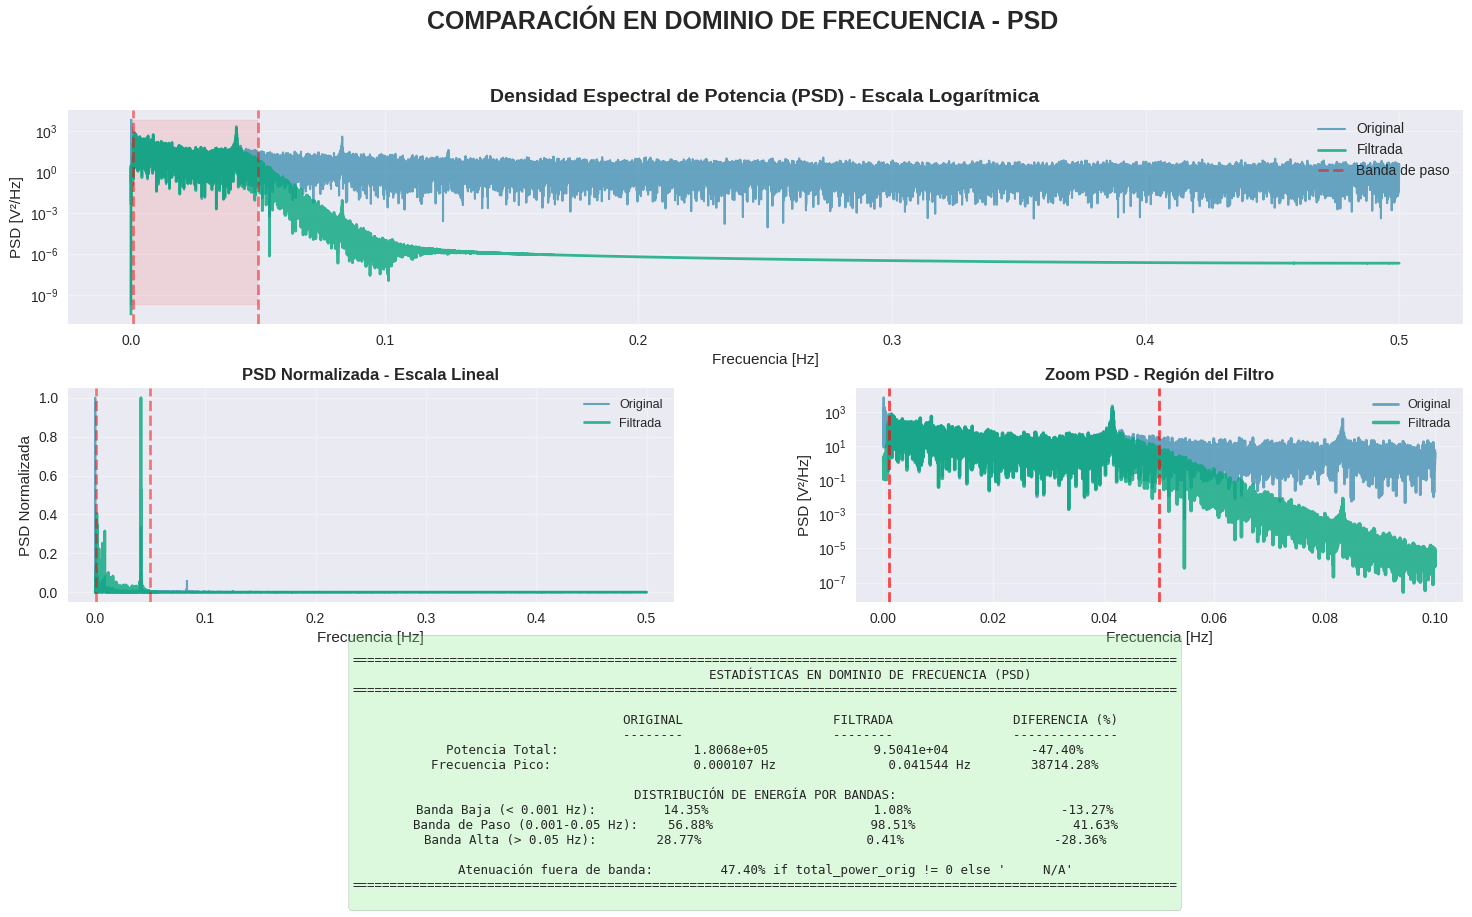

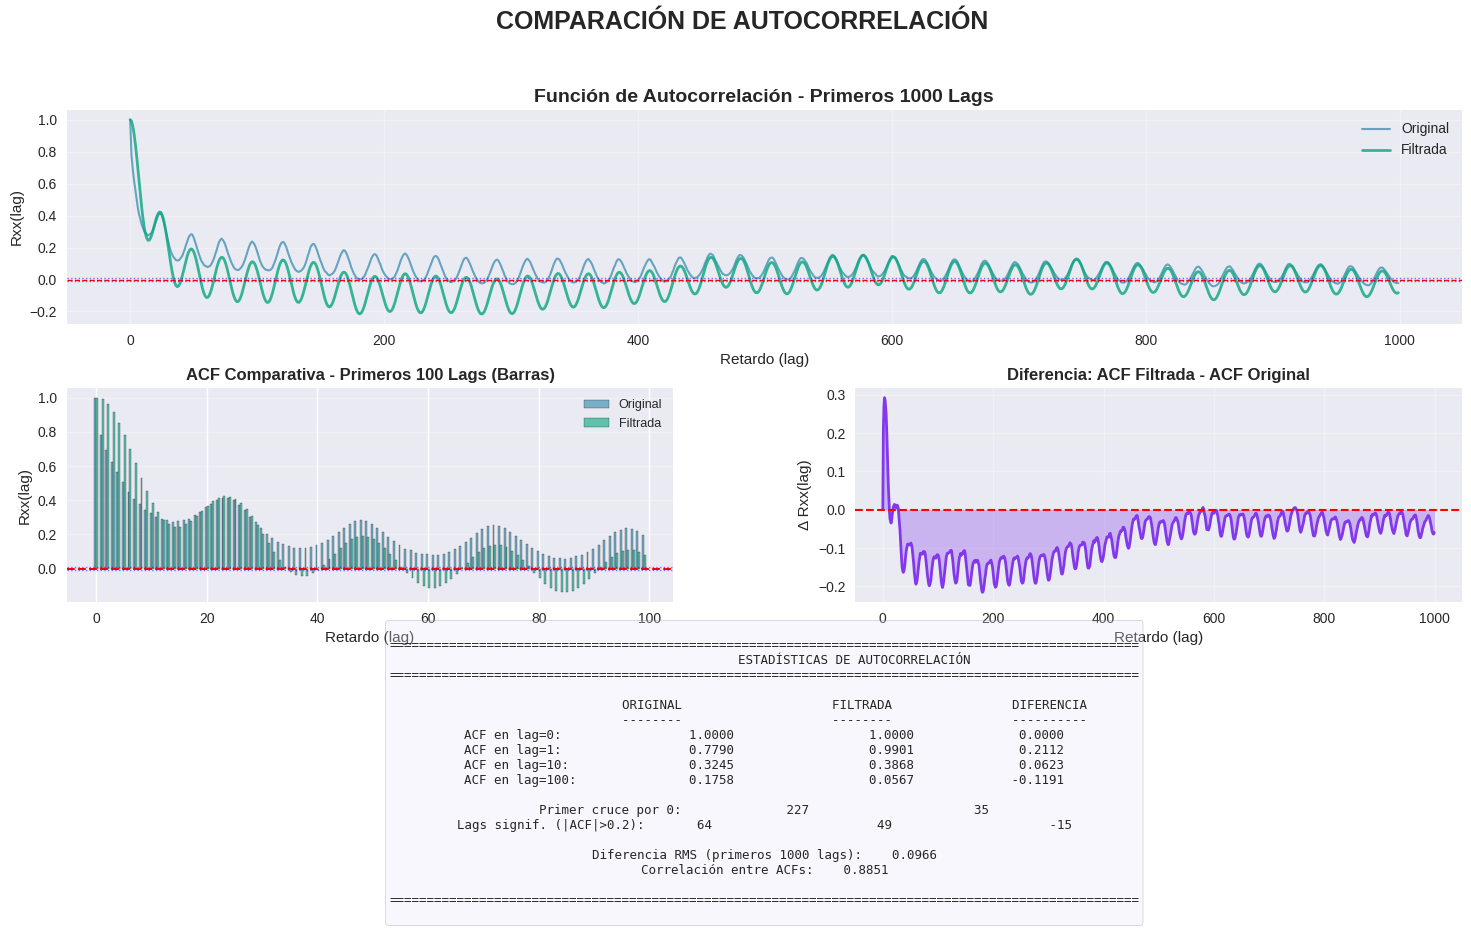

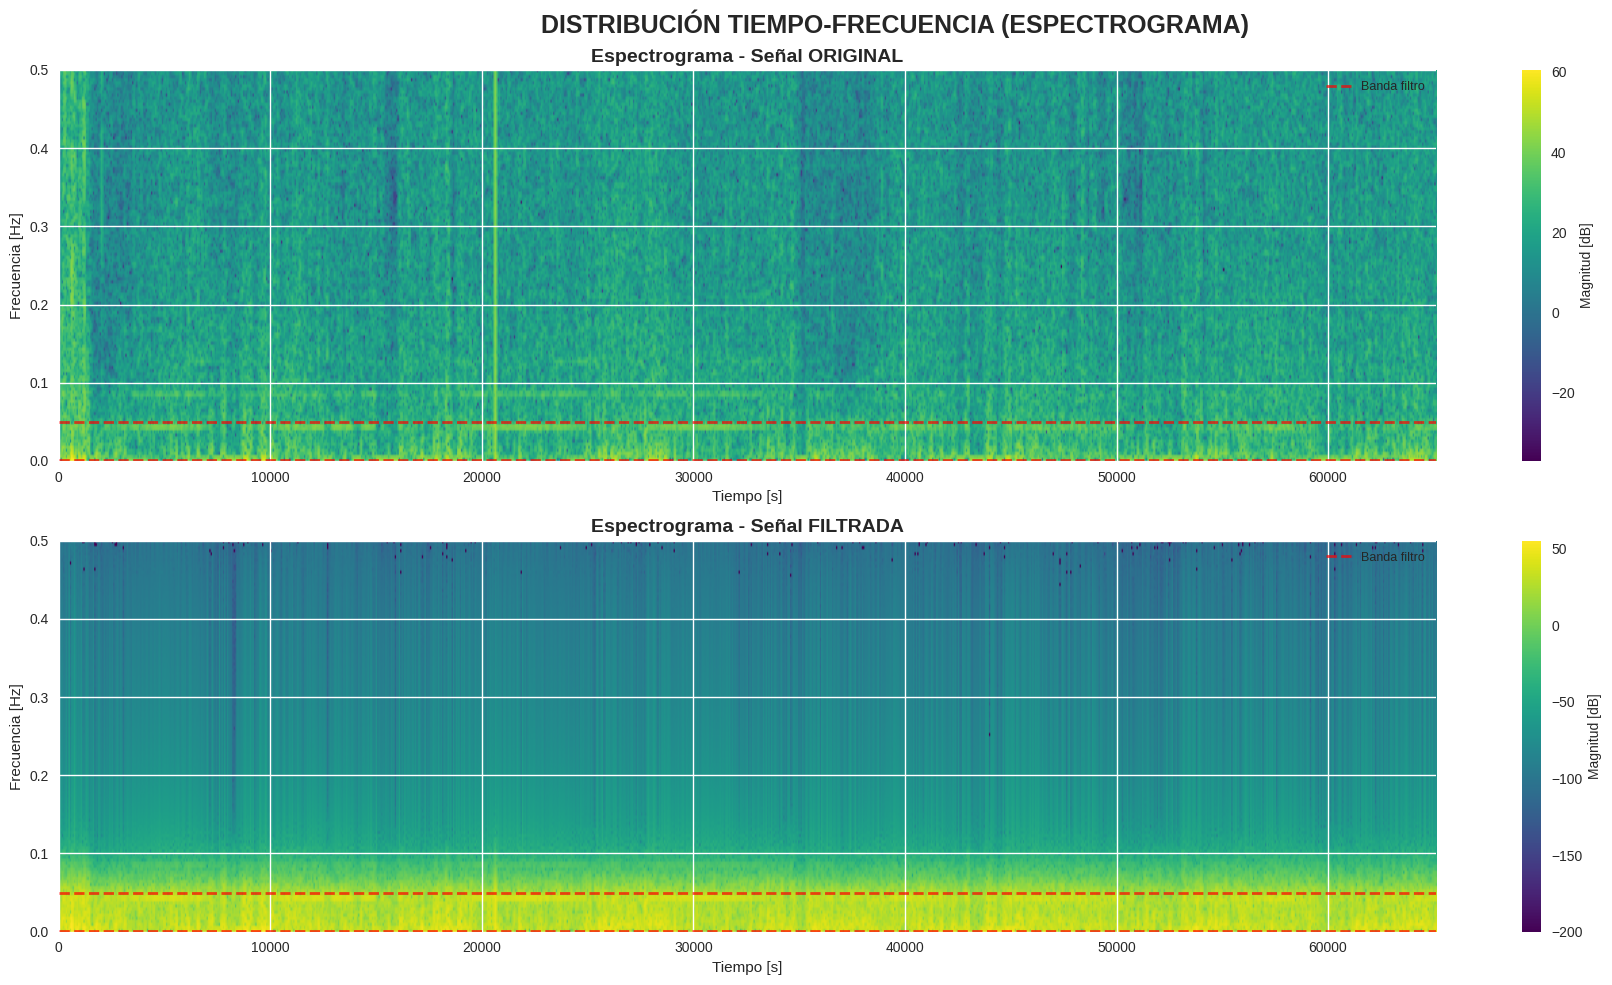

In [22]:
import torch
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.gridspec import GridSpec

plt.style.use("seaborn-v0_8")

# ===============================
# Preparar datos
# ===============================
x_original = torch.tensor(wind_speed_time_series_clean.values, dtype=torch.float32)
# Make a copy of the numpy array to avoid the negative stride issue
x_filtered = torch.tensor(wind_speed_filtered.copy(), dtype=torch.float32)
time_index = wind_speed_time_series_clean.index

# Parámetros de frecuencia de muestreo
if np.issubdtype(time_index.dtype, np.datetime64):
    delta_t = (time_index[1] - time_index[0]).total_seconds()
else:
    delta_t = time_index[1] - time_index[0] if len(time_index) > 1 else 1

fs = 1 / delta_t
nyquist = fs / 2

# ===============================
# Calcular métricas para ambas señales
# ===============================
def calculate_metrics(signal):
    """Calcula todas las métricas para una señal"""
    # Quitar media
    signal_centered = signal - torch.mean(signal)

    # FFT
    fft_signal = torch.fft.fft(signal_centered)
    N = len(signal)

    # PSD (Densidad Espectral de Potencia)
    psd = torch.abs(fft_signal) ** 2 / N
    freqs = torch.fft.fftfreq(N, d=delta_t)

    # Solo frecuencias positivas
    positive_freqs = freqs[:N//2]
    psd_positive = psd[:N//2]

    # Autocorrelación
    acf_full = torch.fft.ifft(torch.abs(fft_signal) ** 2)
    acf = torch.real(acf_full)
    # Handle potential division by zero if acf[0] is 0
    acf = acf / (acf[0] if acf[0] != 0 else 1.0) # Normalize by the value at lag 0

    acf = acf[:N]

    return {
        'fft': fft_signal,
        'psd': psd_positive,
        'freqs': positive_freqs,
        'acf': acf,
        'centered': signal_centered
    }

metrics_original = calculate_metrics(x_original)
metrics_filtered = calculate_metrics(x_filtered)

# ===============================
# FIGURA 1: Comparación en Tiempo
# ===============================
fig1 = plt.figure(figsize=(18, 10))
gs1 = GridSpec(3, 2, figure=fig1, hspace=0.3, wspace=0.3)
fig1.suptitle('COMPARACIÓN EN DOMINIO DEL TIEMPO', fontsize=18, fontweight='bold', y=0.98)

# 1.1 Señales completas
ax1 = fig1.add_subplot(gs1[0, :])
ax1.plot(time_index, x_original.numpy(), color='#2E86AB', linewidth=1,
         alpha=0.7, label='Original')
ax1.plot(time_index, x_filtered.numpy(), color='#06A77D', linewidth=1.5,
         alpha=0.8, label='Filtrada')
ax1.set_title('Señales Completas: Original vs Filtrada', fontsize=14, fontweight='bold')
ax1.set_xlabel('Tiempo', fontsize=11)
ax1.set_ylabel('Velocidad del Viento', fontsize=11)
ax1.legend(loc='upper right', fontsize=10)
ax1.grid(True, alpha=0.3)

# 1.2 Zoom - Primeras 500 muestras
ax2 = fig1.add_subplot(gs1[1, 0])
zoom_samples = min(500, len(x_original))
ax2.plot(range(zoom_samples), x_original[:zoom_samples].numpy(),
         color='#2E86AB', linewidth=1.5, alpha=0.7, label='Original')
ax2.plot(range(zoom_samples), x_filtered[:zoom_samples].numpy(),
         color='#06A77D', linewidth=2, alpha=0.8, label='Filtrada')
ax2.set_title(f'Zoom - Primeras {zoom_samples} Muestras', fontsize=12, fontweight='bold')
ax2.set_xlabel('Muestra', fontsize=11)
ax2.set_ylabel('Amplitud', fontsize=11)
ax2.legend(loc='upper right', fontsize=9)
ax2.grid(True, alpha=0.3)

# 1.3 Histogramas (Distribución de amplitudes)
ax3 = fig1.add_subplot(gs1[1, 1])
ax3.hist(x_original.numpy(), bins=50, alpha=0.6, color='#2E86AB',
         label='Original', density=True, edgecolor='black', linewidth=0.5)
ax3.hist(x_filtered.numpy(), bins=50, alpha=0.6, color='#06A77D',
         label='Filtrada', density=True, edgecolor='black', linewidth=0.5)
ax3.set_title('Distribución de Amplitudes', fontsize=12, fontweight='bold')
ax3.set_xlabel('Amplitud', fontsize=11)
ax3.set_ylabel('Densidad de Probabilidad', fontsize=11)
ax3.legend(loc='upper right', fontsize=9)
ax3.grid(True, alpha=0.3, axis='y')

# 1.4 Estadísticas
ax4 = fig1.add_subplot(gs1[2, :])
ax4.axis('off')

stats_original = {
    'Media': torch.mean(x_original).item(),
    'Desv. Std': torch.std(x_original).item(),
    'Varianza': torch.var(x_original).item(),
    'Máximo': torch.max(x_original).item(),
    'Mínimo': torch.min(x_original).item(),
    'Rango': (torch.max(x_original) - torch.min(x_original)).item(),
    'Energía': torch.sum(x_original ** 2).item(),
    'Potencia': torch.mean(x_original ** 2).item()
}

stats_filtered = {
    'Media': torch.mean(x_filtered).item(),
    'Desv. Std': torch.std(x_filtered).item(),
    'Varianza': torch.var(x_filtered).item(),
    'Máximo': torch.max(x_filtered).item(),
    'Mínimo': torch.min(x_filtered).item(),
    'Rango': (torch.max(x_filtered) - torch.min(x_filtered)).item(),
    'Energía': torch.sum(x_filtered ** 2).item(),
    'Potencia': torch.mean(x_filtered ** 2).item()
}

def format_percentage_diff(original, filtered):
    if original == 0:
        return "     N/A" # Not applicable or cannot calculate percentage
    else:
        return f"{((filtered - original) / original * 100):8.2f}%"

stats_text = f"""
{'='*100}
                        ESTADÍSTICAS EN DOMINIO DEL TIEMPO
{'='*100}

                        ORIGINAL                    FILTRADA                DIFERENCIA (%)
                        --------                    --------                --------------
Media:                  {stats_original['Media']:12.4f}            {stats_filtered['Media']:12.4f}            {format_percentage_diff(stats_original['Media'], stats_filtered['Media'])}
Desv. Std:              {stats_original['Desv. Std']:12.4f}            {stats_filtered['Desv. Std']:12.4f}            {format_percentage_diff(stats_original['Desv. Std'], stats_filtered['Desv. Std'])}
Varianza:               {stats_original['Varianza']:12.4f}            {stats_filtered['Varianza']:12.4f}            {format_percentage_diff(stats_original['Varianza'], stats_filtered['Varianza'])}
Máximo:                 {stats_original['Máximo']:12.4f}            {stats_filtered['Máximo']:12.4f}            {format_percentage_diff(stats_original['Máximo'], stats_filtered['Máximo'])}
Mínimo:                 {stats_original['Mínimo']:12.4f}            {stats_filtered['Mínimo']:12.4f}            {format_percentage_diff(stats_original['Mínimo'], stats_filtered['Mínimo'])}
Rango:                  {stats_original['Rango']:12.4f}            {stats_filtered['Rango']:12.4f}            {format_percentage_diff(stats_original['Rango'], stats_filtered['Rango'])}
Energía Total:          {stats_original['Energía']:12.2f}            {stats_filtered['Energía']:12.2f}            {format_percentage_diff(stats_original['Energía'], stats_filtered['Energía'])}
Potencia Media:         {stats_original['Potencia']:12.4f}            {stats_filtered['Potencia']:12.4f}            {format_percentage_diff(stats_original['Potencia'], stats_filtered['Potencia'])}

{'='*100}
"""

ax4.text(0.5, 0.5, stats_text, fontsize=9, family='monospace',
         verticalalignment='center', horizontalalignment='center',
         bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.3))

plt.savefig('comparacion_tiempo.png', dpi=300, bbox_inches='tight')
plt.show()

# ===============================
# FIGURA 2: Comparación en Frecuencia (PSD)
# ===============================
fig2 = plt.figure(figsize=(18, 10))
gs2 = GridSpec(3, 2, figure=fig2, hspace=0.3, wspace=0.3)
fig2.suptitle('COMPARACIÓN EN DOMINIO DE FRECUENCIA - PSD', fontsize=18, fontweight='bold', y=0.98)

# 2.1 PSD completa (escala logarítmica)
ax5 = fig2.add_subplot(gs2[0, :])
ax5.semilogy(metrics_original['freqs'].numpy(), metrics_original['psd'].numpy(),
             color='#2E86AB', linewidth=1.5, alpha=0.7, label='Original')
ax5.semilogy(metrics_filtered['freqs'].numpy(), metrics_filtered['psd'].numpy(),
             color='#06A77D', linewidth=2, alpha=0.8, label='Filtrada')
# Marcar banda de paso del filtro
ax5.axvline(x=lowcut, color='red', linestyle='--', linewidth=2, alpha=0.5, label=f'Banda de paso')
ax5.axvline(x=highcut, color='red', linestyle='--', linewidth=2, alpha=0.5)
ax5.fill_betweenx([metrics_original['psd'].min().item(), metrics_original['psd'].max().item()],
                   lowcut, highcut, alpha=0.1, color='red')
ax5.set_title('Densidad Espectral de Potencia (PSD) - Escala Logarítmica',
              fontsize=14, fontweight='bold')
ax5.set_xlabel('Frecuencia [Hz]', fontsize=11)
ax5.set_ylabel('PSD [V²/Hz]', fontsize=11)
ax5.legend(loc='upper right', fontsize=10)
ax5.grid(True, alpha=0.3, which='both')

# 2.2 PSD normalizada (lineal)
ax6 = fig2.add_subplot(gs2[1, 0])
psd_orig_norm = metrics_original['psd'] / torch.max(metrics_original['psd'])
psd_filt_norm = metrics_filtered['psd'] / torch.max(metrics_filtered['psd'])
ax6.plot(metrics_original['freqs'].numpy(), psd_orig_norm.numpy(),
         color='#2E86AB', linewidth=1.5, alpha=0.7, label='Original')
ax6.plot(metrics_filtered['freqs'].numpy(), psd_filt_norm.numpy(),
         color='#06A77D', linewidth=2, alpha=0.8, label='Filtrada')
ax6.axvline(x=lowcut, color='red', linestyle='--', linewidth=2, alpha=0.5)
ax6.axvline(x=highcut, color='red', linestyle='--', linewidth=2, alpha=0.5)
ax6.set_title('PSD Normalizada - Escala Lineal', fontsize=12, fontweight='bold')
ax6.set_xlabel('Frecuencia [Hz]', fontsize=11)
ax6.set_ylabel('PSD Normalizada', fontsize=11)
ax6.legend(loc='upper right', fontsize=9)
ax6.grid(True, alpha=0.3)

# 2.3 Zoom en banda de paso
ax7 = fig2.add_subplot(gs2[1, 1])
# Encontrar índices de frecuencias en la banda de paso
freq_mask = (metrics_original['freqs'] >= lowcut * 0.1) & (metrics_original['freqs'] <= highcut * 2)
ax7.semilogy(metrics_original['freqs'][freq_mask].numpy(),
             metrics_original['psd'][freq_mask].numpy(),
             color='#2E86AB', linewidth=2, alpha=0.7, label='Original')
ax7.semilogy(metrics_filtered['freqs'][freq_mask].numpy(),
             metrics_filtered['psd'][freq_mask].numpy(),
             color='#06A77D', linewidth=2.5, alpha=0.8, label='Filtrada')
ax7.axvline(x=lowcut, color='red', linestyle='--', linewidth=2, alpha=0.7)
ax7.axvline(x=highcut, color='red', linestyle='--', linewidth=2, alpha=0.7)
ax7.set_title(f'Zoom PSD - Región del Filtro', fontsize=12, fontweight='bold')
ax7.set_xlabel('Frecuencia [Hz]', fontsize=11)
ax7.set_ylabel('PSD [V²/Hz]', fontsize=11)
ax7.legend(loc='upper right', fontsize=9)
ax7.grid(True, alpha=0.3, which='both')

# 2.4 Estadísticas en frecuencia
ax8 = fig2.add_subplot(gs2[2, :])
ax8.axis('off')

# Calcular métricas espectrales
total_power_orig = torch.sum(metrics_original['psd']).item()
total_power_filt = torch.sum(metrics_filtered['psd']).item()
peak_freq_orig = metrics_original['freqs'][torch.argmax(metrics_original['psd'])].item()
peak_freq_filt = metrics_filtered['freqs'][torch.argmax(metrics_filtered['psd'])].item()

# Energía en diferentes bandas
low_band = metrics_original['freqs'] < lowcut
pass_band = (metrics_original['freqs'] >= lowcut) & (metrics_original['freqs'] <= highcut)
high_band = metrics_original['freqs'] > highcut

energy_orig_low = torch.sum(metrics_original['psd'][low_band]).item() / total_power_orig * 100 if total_power_orig != 0 else 0
energy_orig_pass = torch.sum(metrics_original['psd'][pass_band]).item() / total_power_orig * 100 if total_power_orig != 0 else 0
energy_orig_high = torch.sum(metrics_original['psd'][high_band]).item() / total_power_orig * 100 if total_power_orig != 0 else 0

energy_filt_low = torch.sum(metrics_filtered['psd'][low_band]).item() / total_power_filt * 100 if total_power_filt != 0 else 0
energy_filt_pass = torch.sum(metrics_filtered['psd'][pass_band]).item() / total_power_filt * 100 if total_power_filt != 0 else 0
energy_filt_high = torch.sum(metrics_filtered['psd'][high_band]).item() / total_power_filt * 100 if total_power_filt != 0 else 0

freq_stats_text = f"""
{'='*110}
                            ESTADÍSTICAS EN DOMINIO DE FRECUENCIA (PSD)
{'='*110}

                            ORIGINAL                    FILTRADA                DIFERENCIA (%)
                            --------                    --------                --------------
Potencia Total:             {total_power_orig:15.4e}         {total_power_filt:15.4e}         {format_percentage_diff(total_power_orig, total_power_filt) if total_power_orig != 0 else '     N/A'}
Frecuencia Pico:            {peak_freq_orig:15.6f} Hz        {peak_freq_filt:15.6f} Hz        {format_percentage_diff(peak_freq_orig, peak_freq_filt) if peak_freq_orig != 0 else '     N/A'}

DISTRIBUCIÓN DE ENERGÍA POR BANDAS:
Banda Baja (< {lowcut} Hz):      {energy_orig_low:8.2f}%                  {energy_filt_low:8.2f}%                  {(energy_filt_low-energy_orig_low):8.2f}%
Banda de Paso ({lowcut}-{highcut} Hz): {energy_orig_pass:8.2f}%                  {energy_filt_pass:8.2f}%                  {(energy_filt_pass-energy_orig_pass):8.2f}%
Banda Alta (> {highcut} Hz):     {energy_orig_high:8.2f}%                  {energy_filt_high:8.2f}%                  {(energy_filt_high-energy_orig_high):8.2f}%

Atenuación fuera de banda:      {((1 - total_power_filt/total_power_orig)*100):8.2f}% if total_power_orig != 0 else '     N/A'
{'='*110}
"""

ax8.text(0.5, 0.5, freq_stats_text, fontsize=9, family='monospace',
         verticalalignment='center', horizontalalignment='center',
         bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.3))

plt.savefig('comparacion_frecuencia_psd.png', dpi=300, bbox_inches='tight')
plt.show()

# ===============================
# FIGURA 3: Comparación de Autocorrelación
# ===============================
fig3 = plt.figure(figsize=(18, 10))
gs3 = GridSpec(3, 2, figure=fig3, hspace=0.3, wspace=0.3)
fig3.suptitle('COMPARACIÓN DE AUTOCORRELACIÓN', fontsize=18, fontweight='bold', y=0.98)

lags = torch.arange(len(metrics_original['acf']))
conf_level = 1.96 / torch.sqrt(torch.tensor(len(x_original), dtype=torch.float32))

# 3.1 ACF completa (primeros 1000 lags)
ax9 = fig3.add_subplot(gs3[0, :])
max_lags = min(1000, len(metrics_original['acf']))
ax9.plot(lags[:max_lags].numpy(), metrics_original['acf'][:max_lags].numpy(),
         color='#2E86AB', linewidth=1.5, alpha=0.7, label='Original')
ax9.plot(lags[:max_lags].numpy(), metrics_filtered['acf'][:max_lags].numpy(),
         color='#06A77D', linewidth=2, alpha=0.8, label='Filtrada')
ax9.axhline(y=0, color='red', linestyle='--', linewidth=1)
ax9.axhline(y=conf_level.item(), color='blue', linestyle=':', linewidth=1, alpha=0.5)
ax9.axhline(y=-conf_level.item(), color='blue', linestyle=':', linewidth=1, alpha=0.5)
ax9.set_title('Función de Autocorrelación - Primeros 1000 Lags', fontsize=14, fontweight='bold')
ax9.set_xlabel('Retardo (lag)', fontsize=11)
ax9.set_ylabel('Rxx(lag)', fontsize=11)
ax9.legend(loc='upper right', fontsize=10)
ax9.grid(True, alpha=0.3)

# 3.2 ACF zoom (primeros 100 lags) - Barras
ax10 = fig3.add_subplot(gs3[1, 0])
max_lags_zoom = min(100, len(metrics_original['acf']))
width = 0.35
x_pos = np.arange(max_lags_zoom)
ax10.bar(x_pos - width/2, metrics_original['acf'][:max_lags_zoom].numpy(),
         width, color='#2E86AB', alpha=0.6, label='Original', edgecolor='black', linewidth=0.3)
ax10.bar(x_pos + width/2, metrics_filtered['acf'][:max_lags_zoom].numpy(),
         width, color='#06A77D', alpha=0.6, label='Filtrada', edgecolor='black', linewidth=0.3)
ax10.axhline(y=0, color='red', linestyle='--', linewidth=1.5)
ax10.axhline(y=conf_level.item(), color='blue', linestyle=':', linewidth=1, alpha=0.5)
ax10.axhline(y=-conf_level.item(), color='blue', linestyle=':', linewidth=1, alpha=0.5)
ax10.set_title('ACF Comparativa - Primeros 100 Lags (Barras)', fontsize=12, fontweight='bold')
ax10.set_xlabel('Retardo (lag)', fontsize=11)
ax10.set_ylabel('Rxx(lag)', fontsize=11)
ax10.legend(loc='upper right', fontsize=9)
ax10.grid(True, alpha=0.3, axis='y')

# 3.3 Diferencia de ACF
ax11 = fig3.add_subplot(gs3[1, 1])
diff_acf = metrics_filtered['acf'][:max_lags] - metrics_original['acf'][:max_lags]
ax11.plot(lags[:max_lags].numpy(), diff_acf.numpy(),
          color='#8338EC', linewidth=2)
ax11.fill_between(lags[:max_lags].numpy(), diff_acf.numpy(), 0,
                  alpha=0.3, color='#8338EC')
ax11.axhline(y=0, color='red', linestyle='--', linewidth=1.5)
ax11.set_title('Diferencia: ACF Filtrada - ACF Original', fontsize=12, fontweight='bold')
ax11.set_xlabel('Retardo (lag)', fontsize=11)
ax11.set_ylabel('Δ Rxx(lag)', fontsize=11)
ax11.grid(True, alpha=0.3)

# 3.4 Estadísticas de ACF
ax12 = fig3.add_subplot(gs3[2, :])
ax12.axis('off')

# Encontrar primer cruce por cero
first_zero_orig = torch.where(metrics_original['acf'][:max_lags] < 0)[0]
first_zero_filt = torch.where(metrics_filtered['acf'][:max_lags] < 0)[0]
first_zero_orig = first_zero_orig[0].item() if len(first_zero_orig) > 0 else "No encontrado"
first_zero_filt = first_zero_filt[0].item() if len(first_zero_filt) > 0 else "No encontrado"

# Lags significativos
threshold = 0.2
sig_lags_orig = len(torch.where(torch.abs(metrics_original['acf'][:max_lags]) > threshold)[0])
sig_lags_filt = len(torch.where(torch.abs(metrics_filtered['acf'][:max_lags]) > threshold)[0])

# RMS de la diferencia
rms_diff = torch.sqrt(torch.mean(diff_acf**2)).item()

acf_stats_text = f"""
{'='*100}
                        ESTADÍSTICAS DE AUTOCORRELACIÓN
{'='*100}

                        ORIGINAL                    FILTRADA                DIFERENCIA
                        --------                    --------                ----------
ACF en lag=0:           {metrics_original['acf'][0].item():12.4f}            {metrics_filtered['acf'][0].item():12.4f}            {(metrics_filtered['acf'][0] - metrics_original['acf'][0]).item():8.4f}
ACF en lag=1:           {metrics_original['acf'][1].item():12.4f}            {metrics_filtered['acf'][1].item():12.4f}            {(metrics_filtered['acf'][1] - metrics_original['acf'][1]).item():8.4f}
ACF en lag=10:          {metrics_original['acf'][10].item():12.4f}            {metrics_filtered['acf'][10].item():12.4f}            {(metrics_filtered['acf'][10] - metrics_original['acf'][10]).item():8.4f}
ACF en lag=100:         {metrics_original['acf'][min(100, len(metrics_original['acf'])-1)].item():12.4f}            {metrics_filtered['acf'][min(100, len(metrics_filtered['acf'])-1)].item():12.4f}            {(metrics_filtered['acf'][min(100, len(metrics_filtered['acf'])-1)] - metrics_original['acf'][min(100, len(metrics_original['acf'])-1)]).item():8.4f}

Primer cruce por 0:     {str(first_zero_orig):>12}            {str(first_zero_filt):>12}
Lags signif. (|ACF|>{threshold}): {sig_lags_orig:8d}                {sig_lags_filt:8d}                {(sig_lags_filt - sig_lags_orig):8d}

Diferencia RMS (primeros {max_lags} lags):  {rms_diff:8.4f}
Correlación entre ACFs:  {torch.corrcoef(torch.stack([metrics_original['acf'][:max_lags], metrics_filtered['acf'][:max_lags]]))[0,1].item():8.4f}

{'='*100}
"""

ax12.text(0.5, 0.5, acf_stats_text, fontsize=9, family='monospace',
          verticalalignment='center', horizontalalignment='center',
          bbox=dict(boxstyle='round', facecolor='lavender', alpha=0.3))

plt.savefig('comparacion_autocorrelacion.png', dpi=300, bbox_inches='tight')
plt.show()

# ===============================
# FIGURA 4: Distribución Tiempo-Frecuencia (Espectrograma)
# ===============================
fig4, axes = plt.subplots(2, 1, figsize=(18, 10))
fig4.suptitle('DISTRIBUCIÓN TIEMPO-FRECUENCIA (ESPECTROGRAMA)',
              fontsize=18, fontweight='bold')

# Parámetros para STFT (Short-Time Fourier Transform)
window_size = min(256, len(x_original) // 4)
hop_length = window_size // 4

def compute_spectrogram(signal, window_size, hop_length):
    """Calcula espectrograma usando STFT con PyTorch"""
    signal = signal - torch.mean(signal)

    # Ventana de Hann
    window = torch.hann_window(window_size)

    # STFT
    num_frames = (len(signal) - window_size) // hop_length + 1
    spectrogram = []

    for i in range(num_frames):
        start = i * hop_length
        end = start + window_size
        if end > len(signal):
            break

        frame = signal[start:end] * window
        fft_frame = torch.fft.fft(frame)
        magnitude = torch.abs(fft_frame[:window_size//2])
        spectrogram.append(magnitude)

    spectrogram = torch.stack(spectrogram).T
    return spectrogram

spec_original = compute_spectrogram(x_original, window_size, hop_length)
spec_filtered = compute_spectrogram(x_filtered, window_size, hop_length)

# Convertir a dB
spec_original_db = 20 * torch.log10(spec_original + 1e-10)
spec_filtered_db = 20 * torch.log10(spec_filtered + 1e-10)

# Crear eje de frecuencias y tiempo
freq_axis = torch.linspace(0, fs/2, spec_original.shape[0])
time_axis = torch.arange(spec_original.shape[1]) * hop_length * delta_t

# 4.1 Espectrograma Original
im1 = axes[0].imshow(spec_original_db.numpy(), aspect='auto', origin='lower',
                     cmap='viridis', extent=[0, time_axis[-1].item(), 0, freq_axis[-1].item()])
axes[0].axhline(y=lowcut, color='red', linestyle='--', linewidth=2, alpha=0.7, label='Banda filtro')
axes[0].axhline(y=highcut, color='red', linestyle='--', linewidth=2, alpha=0.7)
axes[0].set_title('Espectrograma - Señal ORIGINAL', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Tiempo [s]', fontsize=11)
axes[0].set_ylabel('Frecuencia [Hz]', fontsize=11)
axes[0].legend(loc='upper right', fontsize=9)
cbar1 = plt.colorbar(im1, ax=axes[0])
cbar1.set_label('Magnitud [dB]', fontsize=10)

# 4.2 Espectrograma Filtrado
im2 = axes[1].imshow(spec_filtered_db.numpy(), aspect='auto', origin='lower',
                     cmap='viridis', extent=[0, time_axis[-1].item(), 0, freq_axis[-1].item()])
axes[1].axhline(y=lowcut, color='red', linestyle='--', linewidth=2, alpha=0.7, label='Banda filtro')
axes[1].axhline(y=highcut, color='red', linestyle='--', linewidth=2, alpha=0.7)
axes[1].set_title('Espectrograma - Señal FILTRADA', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Tiempo [s]', fontsize=11)
axes[1].set_ylabel('Frecuencia [Hz]', fontsize=11)
axes[1].legend(loc='upper right', fontsize=9)
cbar2 = plt.colorbar(im2, ax=axes[1])
cbar2.set_label('Magnitud [dB]', fontsize=10)

plt.tight_layout()
plt.savefig('espectrograma_comparacion.png', dpi=300, bbox_inches='tight')
plt.show()

#**Distribuciones de la señal - PSD VS FILTRADA**

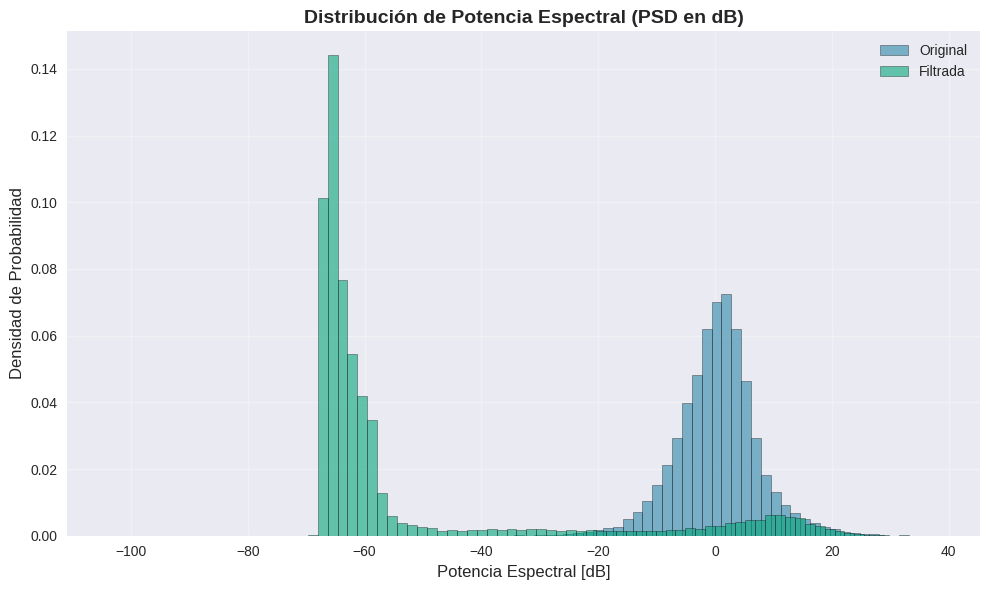

In [33]:
# ===============================
# FIGURA EXTRA: Histogramas de Distribución en Frecuencia (en dB)
# ===============================
plt.figure(figsize=(10,6))

# Convertir PSD a dB con offset para evitar log(0)
psd_orig_db = 10 * torch.log10(metrics_original['psd'] + 1e-12)
psd_filt_db = 10 * torch.log10(metrics_filtered['psd'] + 1e-12)

# Histogramas normalizados
plt.hist(psd_orig_db.numpy(), bins=80, alpha=0.6, color='#2E86AB',
         label='Original', density=True, edgecolor='black', linewidth=0.4)
plt.hist(psd_filt_db.numpy(), bins=80, alpha=0.6, color='#06A77D',
         label='Filtrada', density=True, edgecolor='black', linewidth=0.4)

plt.title("Distribución de Potencia Espectral (PSD en dB)", fontsize=14, fontweight='bold')
plt.xlabel("Potencia Espectral [dB]", fontsize=12)
plt.ylabel("Densidad de Probabilidad", fontsize=12)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("histograma_psd_db.png", dpi=300, bbox_inches="tight")
plt.show()


#**Comparacion de las distribuciones en tiempo y frecuencia**

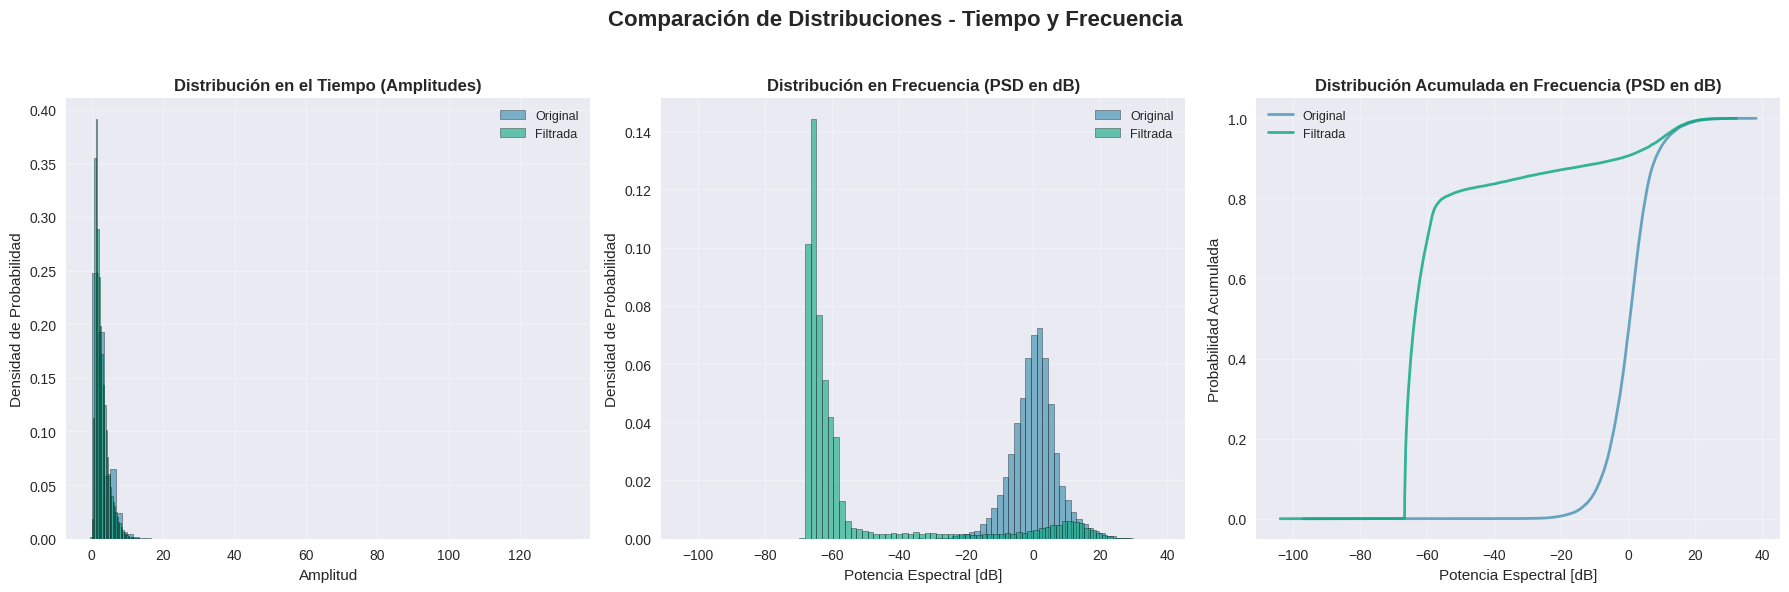

In [34]:
import matplotlib.pyplot as plt
import torch

# ===============================
# FIGURA EXTRA: Comparación de Distribuciones
# ===============================
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("Comparación de Distribuciones - Tiempo y Frecuencia", fontsize=16, fontweight='bold')

# --------------------------------
# 1. Histograma en el dominio del TIEMPO
# --------------------------------
axes[0].hist(x_original.numpy(), bins=80, alpha=0.6, color='#2E86AB',
             label='Original', density=True, edgecolor='black', linewidth=0.4)
axes[0].hist(x_filtered.numpy(), bins=80, alpha=0.6, color='#06A77D',
             label='Filtrada', density=True, edgecolor='black', linewidth=0.4)
axes[0].set_title("Distribución en el Tiempo (Amplitudes)", fontsize=12, fontweight='bold')
axes[0].set_xlabel("Amplitud", fontsize=11)
axes[0].set_ylabel("Densidad de Probabilidad", fontsize=11)
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

# --------------------------------
# 2. Histograma en el dominio de FRECUENCIA (PSD en dB)
# --------------------------------
psd_orig_db = 10 * torch.log10(metrics_original['psd'] + 1e-12)
psd_filt_db = 10 * torch.log10(metrics_filtered['psd'] + 1e-12)

axes[1].hist(psd_orig_db.numpy(), bins=80, alpha=0.6, color='#2E86AB',
             label='Original', density=True, edgecolor='black', linewidth=0.4)
axes[1].hist(psd_filt_db.numpy(), bins=80, alpha=0.6, color='#06A77D',
             label='Filtrada', density=True, edgecolor='black', linewidth=0.4)
axes[1].set_title("Distribución en Frecuencia (PSD en dB)", fontsize=12, fontweight='bold')
axes[1].set_xlabel("Potencia Espectral [dB]", fontsize=11)
axes[1].set_ylabel("Densidad de Probabilidad", fontsize=11)
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

# --------------------------------
# 3. Distribución acumulada (CDF) en frecuencia
# --------------------------------
sorted_orig = torch.sort(psd_orig_db).values.numpy()
cdf_orig = torch.linspace(0, 1, len(sorted_orig))
sorted_filt = torch.sort(psd_filt_db).values.numpy()
cdf_filt = torch.linspace(0, 1, len(sorted_filt))

axes[2].plot(sorted_orig, cdf_orig, color='#2E86AB', linewidth=2, alpha=0.7, label='Original')
axes[2].plot(sorted_filt, cdf_filt, color='#06A77D', linewidth=2, alpha=0.8, label='Filtrada')
axes[2].set_title("Distribución Acumulada en Frecuencia (PSD en dB)", fontsize=12, fontweight='bold')
axes[2].set_xlabel("Potencia Espectral [dB]", fontsize=11)
axes[2].set_ylabel("Probabilidad Acumulada", fontsize=11)
axes[2].legend(fontsize=9)
axes[2].grid(True, alpha=0.3)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig("comparacion_distribuciones.png", dpi=300, bbox_inches="tight")
plt.show()
